In [12]:
import jax.numpy as jnp
import jax.random as random
from jax import jit
from jax.scipy.stats import dirichlet, multivariate_normal, norm
import numpyro
import numpyro.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns


### Generative Probabilistic Process ### 

As it is described in the section 1.3, the steps of the generative process for Gaussian mixture model is the following:

1. Draw the mixture proportions (relative importance of each cluster) from a Dirichlet distribution.


2. Draw a mean mean_k, from a normal distribution centered at zero with a variance of 2\sigma^2_0.

3.1. For each data point n, draw the mixture assignment Z_n, which indicates the cluster that n belongs to.

3.2. Draw the actual datapoint x_n from corresponding Gaussian distribution for each datapoint n.






In [88]:
def gmm(batch_size, n_clusters, n_dim, sigma0, mode, mean_scale=6.0, alpha=None):
  """ This is the solution for the process in 1.3 """


  # parameters for Dirichlet distribution,
  # the weights for the clusters:
  alpha = jnp.ones(shape=(n_clusters,))
  print("Alpha:", alpha)
  print("Sigma0:", sigma0)

  # step: 1, sample the mixture proportions from Dirichlet distribution:
  
  mixture_props = random.dirichlet(random.PRNGKey(0), alpha)    


  means = []

  for k in range(n_clusters):
    if mode == 'Multivariate':
      mean_k = random.normal(random.PRNGKey(k), shape=(n_dim,)) *mean_scale
    if mode == 'Normal':
      mean_k = random.normal(random.PRNGKey(k), shape=(1,)) *mean_scale
    #else:
      #print('Choose one of two modes: Normal or Multivariate')

    means.append(mean_k)

  means = jnp.array(means)

  #Step 2: Sample covariance matrices for each cluster

  covariences = []

  if mode == 'Multivariate':
    for k in range(n_clusters):
      
      cov = jnp.eye(n_dim) * sigma0**2
      covariences.append(cov)

    covariences = jnp.array(covariences)


  #Generate the data points.
  X, Z = [], []


  for n in range(batch_size):
    z_n = random.choice(random.PRNGKey(n), n_clusters, p=mixture_props)
    Z.append(z_n)

    mean_k = means[z_n]

    if mode == 'Multivariate':

      cov_k = covariences[z_n]
      x_n = random.multivariate_normal(random.PRNGKey(n), mean_k, cov_k)

    if mode == 'Normal':
      x_n = random.normal(random.PRNGKey(n), shape=(n_dim,)) * sigma0 + mean_k
    #else:
      #print('Choose one of two modes: Normal or Multivariate')

    X.append(x_n)

  
  X, Z = jnp.array(X), jnp.array(Z)

  return X, Z

In [86]:
### HOW TO USE THE METHOD
#X1, Z1 = gmm(batch_size=1000, n_clusters=4, n_dim=2, sigma0=2, mode= 'Multivariate')
#X2, Z2 = gmm(batch_size=1000, n_clusters=4, n_dim=2, sigma0=10, mode= 'Multivariate')
#X3, Z3 = gmm(batch_size=1000, n_clusters=4, n_dim=2, sigma0=2, mode= 'Normal')
#X4, Z4 = gmm(batch_size=1000, n_clusters=4, n_dim=2, sigma0=10, mode= 'Normal')

### HOW TO PLOT THE RESULTS
def plot_clusters(x, z, ax, title):
  # visualizing the mixture
  num_clusters = len(np.unique(z))
  cluster_indices = [i % num_clusters for i in z]
  cluster_colors = sns.color_palette("hls", num_clusters)
  ax.scatter(x[:, 0], x[:, 1], c=[cluster_colors[i] for i in cluster_indices], s=6)
  ax.set_title(title)
  ax.set_xticks([])
  ax.set_yticks([])


Alpha: [1. 1.]
Sigma0: 0.5
Alpha: [1. 1.]
Sigma0: 1
Alpha: [1. 1.]
Sigma0: 2
Alpha: [1. 1. 1. 1.]
Sigma0: 0.5
Alpha: [1. 1. 1. 1.]
Sigma0: 1
Alpha: [1. 1. 1. 1.]
Sigma0: 2
Alpha: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Sigma0: 0.5
Alpha: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Sigma0: 1
Alpha: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Sigma0: 2
Alpha: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 

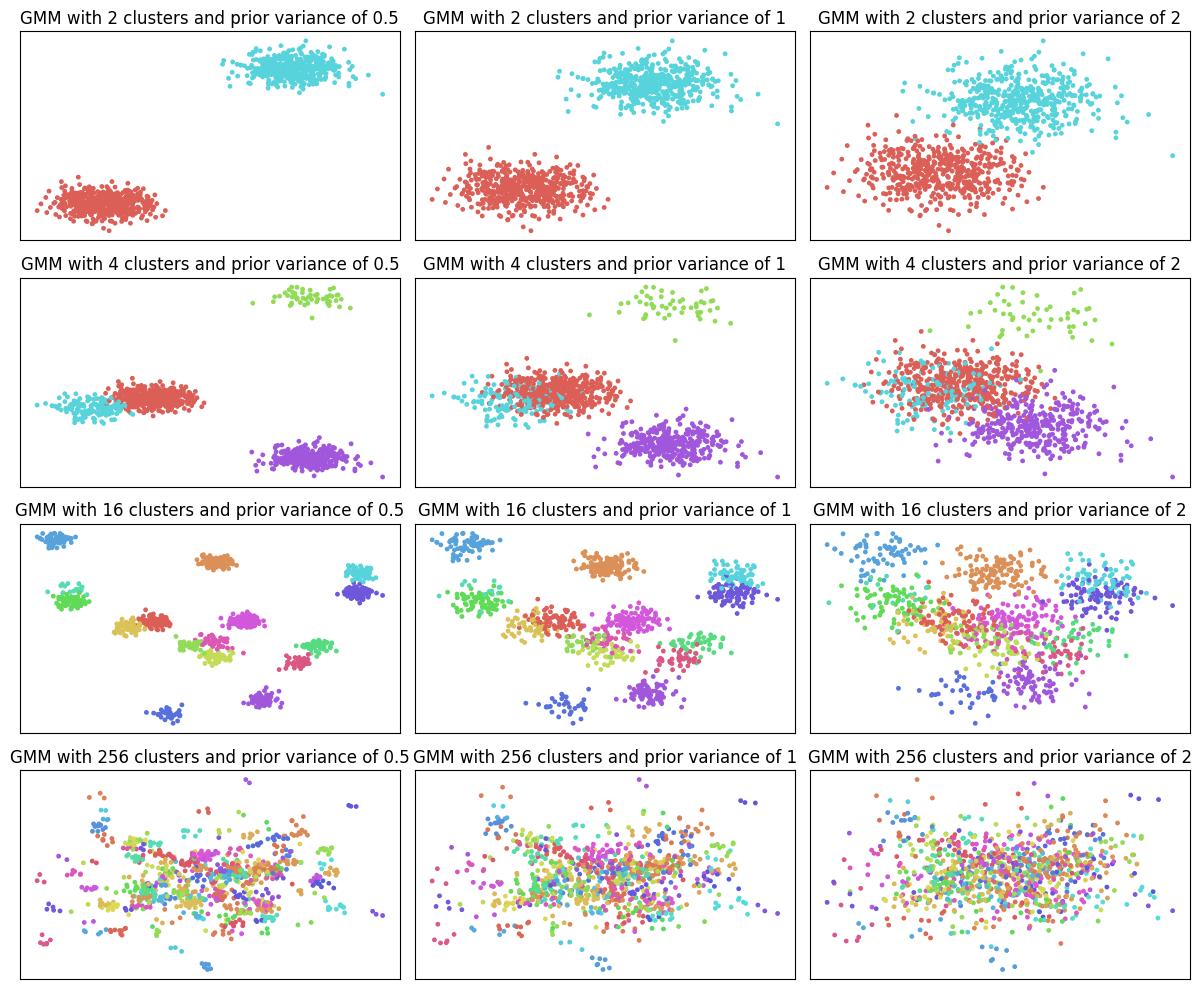

In [90]:
#Question 4 hyperparameters:

batch_size = 1000
n_dim = 2

#set Dirichlet uninformative prior up to 256 clusters:

alpha = np.ones(256)
mean_scale = 5.0
K = [2,4,16,256] #given
prior_var = [0.5, 1, 2]
fig, axes = plt.subplots(len(K),len(prior_var), figsize= (12, 10))


for row_idx, k in enumerate(K):
    for col_idx, sigma in enumerate(prior_var):
        X, Z = gmm(batch_size=batch_size, n_clusters=k, n_dim=n_dim,  sigma0=sigma, mode= 'Multivariate', alpha= alpha[:k])

        
        plot_clusters(X, Z, axes[row_idx, col_idx], f"GMM with {k} clusters and prior variance of {sigma}")

plt.tight_layout()
plt.show()